# What machine learning actually does

### The whole workflow on one small problem, with the baseline kept in view the entire time

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a supervised model is doing, why the first thing to build is the dumbest possible predictor, how to split data so a score means something, how to read the score you get, and what would have to be true before anyone should use the model |
| **You should already know** | Python and pandas well enough to read a `DataFrame`. No machine learning at all |
| **Datasets** | California Housing, 20,640 districts. Ships with scikit-learn, so this notebook runs with nothing downloaded. Breast Cancer Wisconsin for the classification version |
| **Runtime** | Under a minute on a laptop CPU |
| **Next** | [01-02 Train, validation, test](../02-train-validation-test/) |

---

## 1. The idea, before any notation

You have a table. One column is the thing you want to know and the others are
things you already know. Machine learning is the business of turning the second
group into a guess at the first, using rows where you happen to have both.

That is the entire premise. Everything else in this book is a variation on it:
a different shape of guess, a different way of measuring how wrong it is, a
different reason the measurement lies to you.

The part that beginners skip, and the part this chapter is built around, is
**how good is good**. A model that predicts house prices with an average error
of fifty thousand dollars sounds either impressive or useless, and the sentence
alone cannot tell you which. It becomes answerable the moment you ask what the
error would have been if you had not built a model at all. Predict the same
number for every district, the average of the ones you have seen, and measure
that. Now the model has something to beat, and the size of what it beats it by
is the only part of its score that it earned.

I will call that number the **baseline**, and it appears in every section below.

### The workflow, in the order it happens

1. Load the data and look at it, before touching a model
2. Split it, so some rows are kept back
3. Build the baseline and score it
4. Fit a model and score it the same way
5. Subtract, and report the margin
6. Look at where the model is wrong, not only at how wrong it is on average
7. Write down what would have to hold for the thing to be used

Seven steps, no shortcuts, and step 3 is the one everybody drops.

In [1]:
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, datasets

style.use()
FIG = pathlib.Path("figures")
FIG.mkdir(exist_ok=True)
SEED = 0

## 2. Load it, and look at it first

California Housing is one row per census district in California in 1990. The
target is the median house value in that district, in hundreds of thousands of
dollars.

Before any model, three questions. How big is the table, what is in the
columns, and is anything missing.

In [2]:
X, y = datasets.california_housing()

print(f"rows    : {len(X):,}")
print(f"columns : {X.shape[1]}")
print(f"target  : {y.name}, median house value in hundreds of thousands of dollars\n")
print(X.dtypes.to_string())
print(f"\nmissing values anywhere in the features: {int(X.isna().sum().sum())}")
print(f"missing values in the target           : {int(y.isna().sum())}\n")
print(X.head(3).to_string())

rows    : 20,640
columns : 8
target  : MedHouseVal, median house value in hundreds of thousands of dollars

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64

missing values anywhere in the features: 0
missing values in the target           : 0

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24


Every column is numeric and nothing is missing, which is unusual and is the
reason this dataset opens the book rather than one that would need a chapter of
cleaning first. [01-07](../07-feature-scaling-and-encoding/) handles columns
that are text, and [01-08](../08-missing-data/) handles holes.

Now the target, which is where the surprises live.

In [3]:
print(y.describe().to_string())

capped = int((y >= 5.0).sum())
print(f"\ndistricts sitting exactly at the top value: {capped} ({capped / len(y):.2%})")
print(f"largest value in the target: {y.max():.4f}")
print(f"second largest distinct value: {np.sort(y.unique())[-2]:.4f}")

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010

districts sitting exactly at the top value: 992 (4.81%)
largest value in the target: 5.0000
second largest distinct value: 5.0000


There it is. The target was capped when the data was collected: every district
worth more than the cap was recorded at the cap. Those rows do not carry the
value they should, and no model can recover a number that was never written
down.

This matters later, so it goes in the notes now rather than being discovered
halfway through a results table. Looking at the target for ten seconds bought
that.

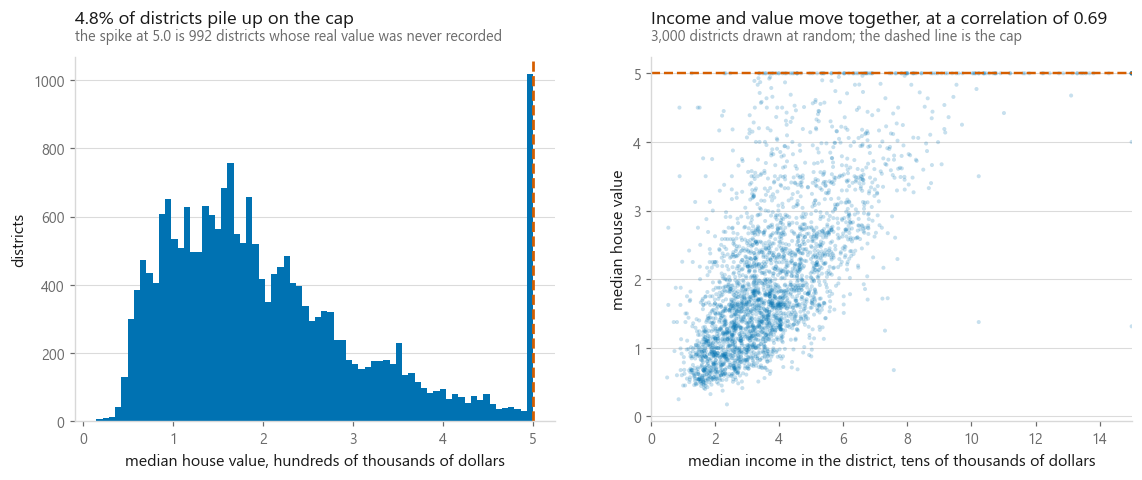

In [4]:
rng = np.random.default_rng(SEED)
sample = rng.choice(len(X), 3000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

axes[0].hist(y, bins=70, color=style.PALETTE[0])
axes[0].axvline(5.0, color=style.HIGHLIGHT, ls="--", lw=1.8)
axes[0].set_xlabel("median house value, hundreds of thousands of dollars")
axes[0].set_ylabel("districts")
style.title(axes[0],
            f"{capped / len(y):.1%} of districts pile up on the cap",
            f"the spike at 5.0 is {capped:,} districts whose real value was never recorded")

axes[1].scatter(X["MedInc"].to_numpy()[sample], y.to_numpy()[sample],
                s=7, alpha=0.22, color=style.PALETTE[0], edgecolors="none")
axes[1].axhline(5.0, color=style.HIGHLIGHT, ls="--", lw=1.6)
axes[1].set_xlabel("median income in the district, tens of thousands of dollars")
axes[1].set_ylabel("median house value")
axes[1].set_xlim(0, 15)
corr = float(np.corrcoef(X["MedInc"], y)[0, 1])
style.title(axes[1],
            f"Income and value move together, at a correlation of {corr:.2f}",
            f"{len(sample):,} districts drawn at random; the dashed line is the cap")

style.save(fig, FIG / "fig-01-look-first.png")

The left panel is the cap. The right panel is the reason a model is worth
fitting at all: the cloud slopes upward, so income carries information about
price. It is also wide, which is the reason one column will not be enough.

## 3. The maths, kept to what you need

Write a row of features as $x$ and its target as $y$. A model is a function
$\hat{f}$ that turns one into the other, and fitting means choosing $\hat{f}$
from a family of candidates so that the mistakes on the rows you have are
small.

For a numeric target the standard measure of a mistake is the **root mean
squared error**:

$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\big(y_i - \hat{f}(x_i)\big)^2}$$

It is in the units of the target, which is why I lead with it. Squaring means a
single terrible prediction costs more than several mediocre ones, so RMSE is a
measure that cares about the worst cases.

The baseline falls straight out of the same formula. Take the family of
candidates to be the constants, so $\hat{f}(x) = c$ for every row. Differentiate
the squared error with respect to $c$ and the minimum sits at the mean of $y$.
**Predicting the mean is not a strawman, it is the exact solution to the problem
when the features are ignored.** That is what makes it the right thing to beat.

One more definition, because it is the baseline in disguise:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{f}(x_i))^2}{\sum_i (y_i - \bar{y})^2}$$

The numerator is the model's squared error and the denominator is the constant
predictor's. So $R^2$ is already a margin: zero means you matched the mean, one
means perfection, and negative means you did worse than a number that took no
effort to compute. I will check that identity against the library rather than
assert it.

## 4. From scratch, so nothing is magic

Two models in NumPy before any import from scikit-learn. The constant, and a
straight line through one column.

In [5]:
def fit_constant(y_train):
    """The optimal constant predictor. This is the baseline, in full."""
    return float(np.mean(y_train))


def fit_line(x_train, y_train):
    """Least squares slope and intercept for one feature, closed form."""
    x_bar, y_bar = x_train.mean(), y_train.mean()
    slope = np.sum((x_train - x_bar) * (y_train - y_bar)) / np.sum((x_train - x_bar) ** 2)
    return float(slope), float(y_bar - slope * x_bar)


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


x_income = X["MedInc"].to_numpy()
y_all = y.to_numpy()

c_hat = fit_constant(y_all)
slope, intercept = fit_line(x_income, y_all)

print(f"constant predictor            : {c_hat:.4f}")
print(f"line through MedInc           : value = {slope:.4f} * income + {intercept:.4f}\n")
print(f"RMSE, constant                : {rmse(y_all, np.full_like(y_all, c_hat)):.4f}")
print(f"RMSE, one-feature line        : {rmse(y_all, slope * x_income + intercept):.4f}")

constant predictor            : 2.0686
line through MedInc           : value = 0.4179 * income + 0.4509

RMSE, constant                : 1.1539
RMSE, one-feature line        : 0.8373


In [6]:
# The same line from the library, to show the closed form above is the whole thing.
from sklearn.linear_model import LinearRegression

sk_line = LinearRegression().fit(x_income.reshape(-1, 1), y_all)
print(f"my slope     {slope:.12f}")
print(f"sklearn      {float(sk_line.coef_[0]):.12f}")
print(f"difference   {abs(slope - float(sk_line.coef_[0])):.2e}")

my slope     0.417938492019
sklearn      0.417938492019
difference   4.44e-16


Nothing is hidden inside `LinearRegression` beyond that arithmetic, done for
many columns at once. [02-01](../../02-regression/01-linear-regression/) derives
the many-column version and explains why it uses a solver rather than the matrix
inverse the formula suggests.

## 5. Split, before fitting anything you intend to trust

Both numbers above are wrong, in the specific way that matters most in this
book. They were computed on the same rows the models were fitted on, so they
measure memory rather than skill. A model that memorises the answers scores
perfectly and predicts nothing.

The fix is to hide some rows before fitting and score on those. One argument
about how large the hidden part should be, one seed written down, and the rest
of the notebook can be believed.

[01-02](../02-train-validation-test/) explains why two pieces are not enough
once you start choosing between models, and [01-04](../04-cross-validation/)
explains why a single split is a noisy way to do this at all. For a first look,
one split is honest and easy to see.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

print(f"training rows : {len(X_train):,}")
print(f"held-out rows : {len(X_test):,}\n")
print(f"mean target, training : {y_train.mean():.4f}")
print(f"mean target, held out : {y_test.mean():.4f}")
print(f"share at the cap, training : {(y_train >= 5.0).mean():.4f}")
print(f"share at the cap, held out : {(y_test >= 5.0).mean():.4f}")

training rows : 16,512
held-out rows : 4,128

mean target, training : 2.0725
mean target, held out : 2.0528
share at the cap, training : 0.0489
share at the cap, held out : 0.0448


The two halves look like each other, which is what a random split of a large
table should produce. When they do not, the split was wrong for the data, and
[01-02](../02-train-validation-test/) covers the two common cases: rows that
come in groups, and rows that come in time order.

## 6. The baseline, then the model, then the subtraction

`DummyRegressor` is the library's version of section 4's constant. It exists
for exactly this purpose and it takes one line, which removes the last excuse
for not having a baseline.

In [8]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)

# Scaling does not change a linear model's predictions, but it puts the
# coefficients in comparable units, which section 7 needs. The scaler lives
# inside a Pipeline so it is fitted on training rows only.
linear = Pipeline([("scale", StandardScaler()),
                   ("model", LinearRegression())]).fit(X_train, y_train)

boosted = HistGradientBoostingRegressor(random_state=SEED).fit(X_train, y_train)

base_rmse = root_mean_squared_error(y_test, baseline.predict(X_test))

scores = []
for name, model in [("predict the mean", baseline),
                    ("linear regression", linear),
                    ("gradient boosting", boosted)]:
    pred = model.predict(X_test)
    scores.append({
        "model": name,
        "RMSE": root_mean_squared_error(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred),
        "RMSE beaten by": base_rmse - root_mean_squared_error(y_test, pred),
        "% better than baseline": 100 * (1 - root_mean_squared_error(y_test, pred) / base_rmse),
    })

scores = pd.DataFrame(scores)
print(scores.to_string(index=False, formatters={
    "RMSE": "{:.4f}".format, "MAE": "{:.4f}".format, "R2": "{:+.4f}".format,
    "RMSE beaten by": "{:+.4f}".format, "% better than baseline": "{:+.1f}".format}))

            model   RMSE    MAE      R2 RMSE beaten by % better than baseline
 predict the mean 1.1421 0.9071 -0.0003        +0.0000                   +0.0
linear regression 0.7273 0.5351 +0.5943        +0.4148                  +36.3
gradient boosting 0.4595 0.3090 +0.8381        +0.6826                  +59.8


That table is the shape every result in this book takes. A score on its own is
not a result. A score next to the score of doing nothing is.

Note the baseline's $R^2$. It is not exactly zero, and the reason is worth
thirty seconds. `r2_score` compares against the mean of the **held-out** target,
while the baseline you could actually ship predicts the mean of the **training**
target. Those are different numbers, so the deployable constant scores a shade
below zero.

In [9]:
pred_linear = linear.predict(X_test)

mse_model = float(np.mean((y_test - pred_linear) ** 2))
mse_test_mean = float(np.mean((y_test - y_test.mean()) ** 2))
mse_train_mean = float(np.mean((y_test - y_train.mean()) ** 2))

print(f"1 - mse(model) / mse(test mean)  : {1 - mse_model / mse_test_mean:.8f}")
print(f"r2_score from the library        : {r2_score(y_test, pred_linear):.8f}")
print(f"identical to 8 decimals          : "
      f"{np.isclose(1 - mse_model / mse_test_mean, r2_score(y_test, pred_linear))}\n")
print(f"1 - mse(model) / mse(train mean) : {1 - mse_model / mse_train_mean:.8f}")
print(f"the gap between the two references: "
      f"{abs(mse_test_mean - mse_train_mean) / mse_test_mean:.2e} of the total")

1 - mse(model) / mse(test mean)  : 0.59432327
r2_score from the library        : 0.59432327
identical to 8 decimals          : True

1 - mse(model) / mse(train mean) : 0.59444402
the gap between the two references: 2.98e-04 of the total


So $R^2$ really is one minus the ratio of squared errors, and the constant it
compares against is the test set's own mean. On a split this size the two
references agree to a rounding error. On a small or unlucky split they do not,
which is one more reason [01-04](../04-cross-validation/) exists.

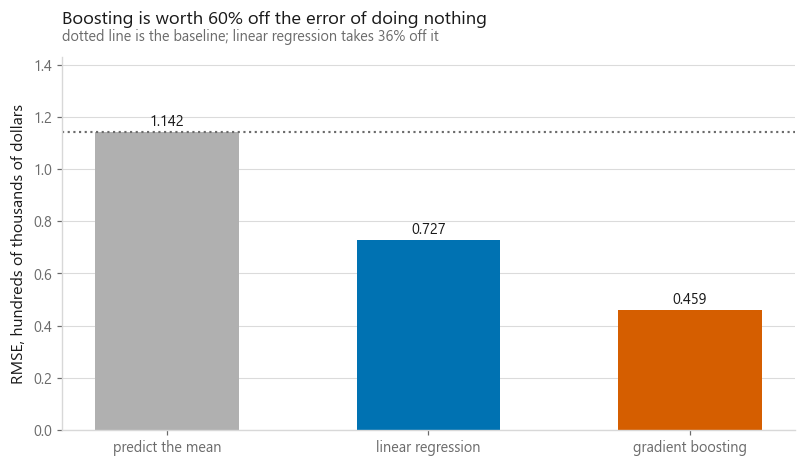

In [10]:
fig, ax = plt.subplots(figsize=(8.6, 4.4))

names = scores["model"].tolist()
values = scores["RMSE"].to_numpy()
colours = [style.NEUTRAL, style.PALETTE[0], style.HIGHLIGHT]
bars = ax.bar(names, values, color=colours, width=0.55)

# Bars start at zero, so the eye compares lengths honestly and the gap to the
# baseline is the visible quantity rather than a cropped difference.
ax.set_ylim(0, values.max() * 1.25)
ax.set_ylabel("RMSE, hundreds of thousands of dollars")
for bar, value in zip(bars, values):
    ax.annotate(f"{value:.3f}", (bar.get_x() + bar.get_width() / 2, value),
                xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9.5, color=style.INK)

ax.axhline(base_rmse, color=style.MUTED, ls=":", lw=1.4)
best = scores.loc[scores["RMSE"].idxmin()]
style.title(ax,
            f"Boosting is worth {best['% better than baseline']:.0f}% off the error of doing nothing",
            f"dotted line is the baseline; linear regression takes "
            f"{scores.loc[1, '% better than baseline']:.0f}% off it")

style.save(fig, FIG / "fig-02-margin-over-baseline.png")

## 7. Interpret it, carefully

The linear model is a weighted sum, so its weights can be read. Because the
features went through a scaler first, each weight answers the same question:
how much does the prediction move when this column moves by one standard
deviation, holding the others still.

I expected income to carry the largest weight. The title below is computed at
plot time from the fitted model, so it names whichever feature actually won.

Latitude     -0.9004
Longitude    -0.8706
MedInc       +0.8262
AveBedrms    +0.2904
AveRooms     -0.2489
HouseAge     +0.1171
AveOccup     -0.0306
Population   -0.0086


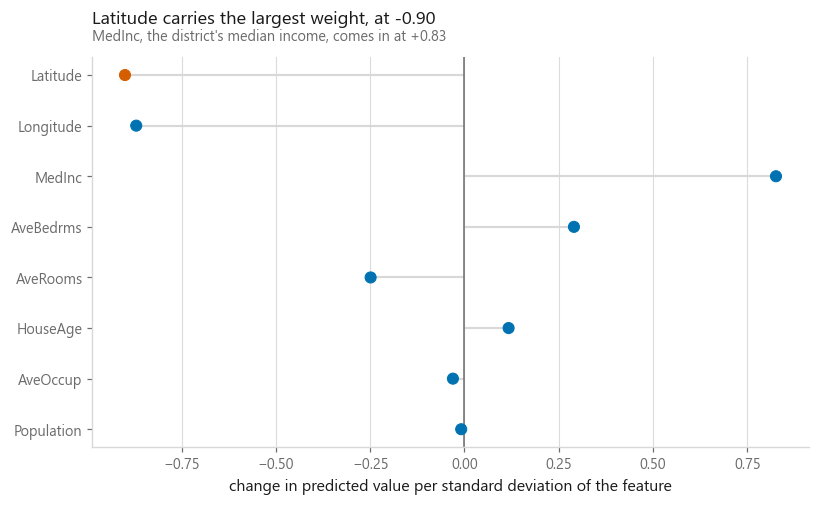

In [11]:
coefficients = pd.Series(linear.named_steps["model"].coef_, index=X.columns)
ordered = coefficients.reindex(coefficients.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.hlines(range(len(ordered)), 0, ordered.to_numpy(), color=style.RULE, lw=1.4)
ax.scatter(ordered.to_numpy(), range(len(ordered)),
           color=[style.HIGHLIGHT if abs(v) == ordered.abs().max() else style.PALETTE[0]
                  for v in ordered],
           marker=style.MARKERS[0], s=52, zorder=3)
ax.axvline(0, color=style.MUTED, lw=1.0)
ax.set_yticks(range(len(ordered)), ordered.index)
ax.set_xlabel("change in predicted value per standard deviation of the feature")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)

winner = coefficients.abs().idxmax()
style.title(ax,
            f"{winner} carries the largest weight, at {coefficients[winner]:+.2f}",
            f"MedInc, the district's median income, comes in at "
            f"{coefficients['MedInc']:+.2f}")

style.save(fig, FIG / "fig-03-coefficients.png")

print(coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)
      .to_string(float_format="{:+.4f}".format))

Latitude and longitude beat income, and
[02-01](../../02-regression/01-linear-regression/) hit the same result and
explains it: the model is spending weight on drawing the California coastline
with two straight lines, which is a clumsy use of a linear model and a preview
of why trees do better here.

One warning that this book will repeat until it is boring. **A coefficient is a
statement about the model, not about the world.** It does not say that moving a
district north would lower its house prices.
[12-02](../../12-putting-it-together/02-interpreting-models/) measures how badly
this goes wrong, including a case where copying a column made the original look
unimportant.

### Where the model is wrong, not just how much

An average error is a summary and summaries hide structure. Group the held-out
rows by how expensive they truly are, and look at the average signed error
inside each group.

In [12]:
deciles = pd.qcut(y_test, 10, labels=False, duplicates="drop")
by_decile = pd.DataFrame({
    "decile": deciles,
    "true": y_test.to_numpy(),
    "error": pred_linear - y_test.to_numpy(),
}).groupby("decile").agg(mean_true=("true", "mean"),
                         mean_error=("error", "mean"),
                         rows=("error", "size"))

overall_bias = float(np.mean(pred_linear - y_test.to_numpy()))
cheapest = float(by_decile["mean_error"].iloc[0])
dearest = float(by_decile["mean_error"].iloc[-1])

print(by_decile.to_string(float_format="{:+.4f}".format))
print(f"\naverage error over all held-out rows : {overall_bias:+.4f}")
print(f"average error in the cheapest decile : {cheapest:+.4f}")
print(f"average error in the dearest decile  : {dearest:+.4f}")

        mean_true  mean_error  rows
decile                             
0         +0.6505     +0.3284   413
1         +0.9446     +0.3483   414
2         +1.1936     +0.3901   414
3         +1.4415     +0.3347   410
4         +1.6601     +0.2900   413
5         +1.9132     +0.1871   413
6         +2.2446     +0.0406   412
7         +2.6396     -0.1301   414
8         +3.2650     -0.5460   412
9         +4.5776     -1.1395   413

average error over all held-out rows : +0.0104
average error in the cheapest decile : +0.3284
average error in the dearest decile  : -1.1395


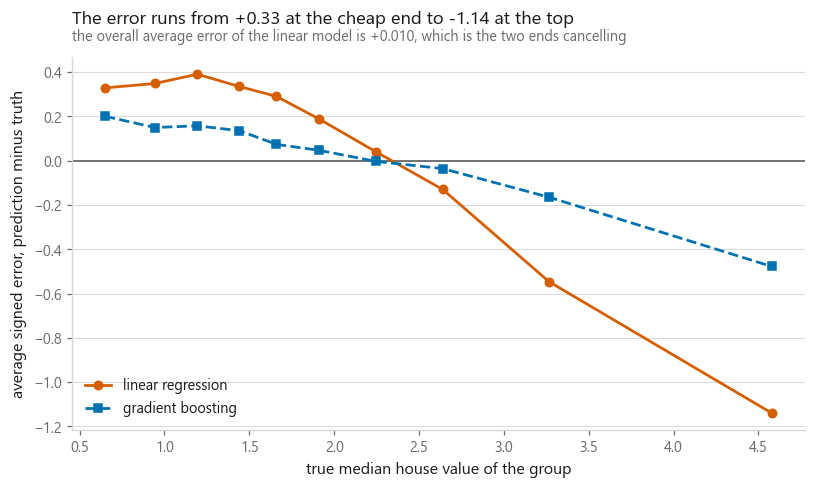

In [13]:
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.axhline(0, color=style.MUTED, lw=1.2)
ax.plot(by_decile["mean_true"], by_decile["mean_error"],
        color=style.HIGHLIGHT, marker=style.MARKERS[0], lw=1.8, ls="-",
        label="linear regression")

boost_error = boosted.predict(X_test) - y_test.to_numpy()
by_decile_boost = pd.DataFrame({"decile": deciles, "true": y_test.to_numpy(),
                                "error": boost_error}).groupby("decile").agg(
    mean_true=("true", "mean"), mean_error=("error", "mean"))
ax.plot(by_decile_boost["mean_true"], by_decile_boost["mean_error"],
        color=style.PALETTE[0], marker=style.MARKERS[1], lw=1.8, ls="--",
        label="gradient boosting")

ax.set_xlabel("true median house value of the group")
ax.set_ylabel("average signed error, prediction minus truth")
ax.legend(loc="lower left")
style.title(ax,
            f"The error runs from {cheapest:+.2f} at the cheap end to {dearest:+.2f} at the top",
            f"the overall average error of the linear model is {overall_bias:+.3f}, "
            f"which is the two ends cancelling")

style.save(fig, FIG / "fig-04-where-it-is-wrong.png")

The overall average error printed above sits near zero, and the table shows why:
the two ends of the price range are biased in opposite directions and cancel. The
top decile is partly the cap from section 2, since those districts were recorded
at 5.0 when they were worth more, so a model predicting below 5.0 for them is
being scored against a number that was never true.

This is the single habit worth taking from the chapter. **Break the error down
by something, always.** A summary statistic that looked fine hid a structural
failure, and it took one `groupby` to see it.

## 8. The same seven steps, on a yes-or-no question

Nothing above depended on the target being a number. Swap in a target with two
values and the workflow is identical: the baseline becomes the majority class,
the metric becomes accuracy, and the subtraction still decides whether the model
was worth building.

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

X_bc, y_bc = datasets.breast_cancer()
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=SEED, stratify=y_bc)

majority = DummyClassifier(strategy="most_frequent").fit(Xb_train, yb_train)
logistic = Pipeline([("scale", StandardScaler()),
                     ("model", LogisticRegression(max_iter=5000))]).fit(Xb_train, yb_train)

base_acc = majority.score(Xb_test, yb_test)
model_acc = logistic.score(Xb_test, yb_test)

print(f"rows: {len(X_bc)}, features: {X_bc.shape[1]}")
print(f"class balance in training: "
      f"{yb_train.value_counts(normalize=True).round(4).to_dict()}\n")
print(f"always predict the majority class : {base_acc:.4f}")
print(f"logistic regression               : {model_acc:.4f}")
print(f"margin                            : {model_acc - base_acc:+.4f}")
print(f"errors removed                    : "
      f"{(1 - model_acc) / (1 - base_acc):.3f} of the baseline's error rate remains")

rows: 569, features: 30
class balance in training: {1: 0.6264, 0: 0.3736}

always predict the majority class : 0.6316
logistic regression               : 0.9825
margin                            : +0.3509
errors removed                    : 0.048 of the baseline's error rate remains


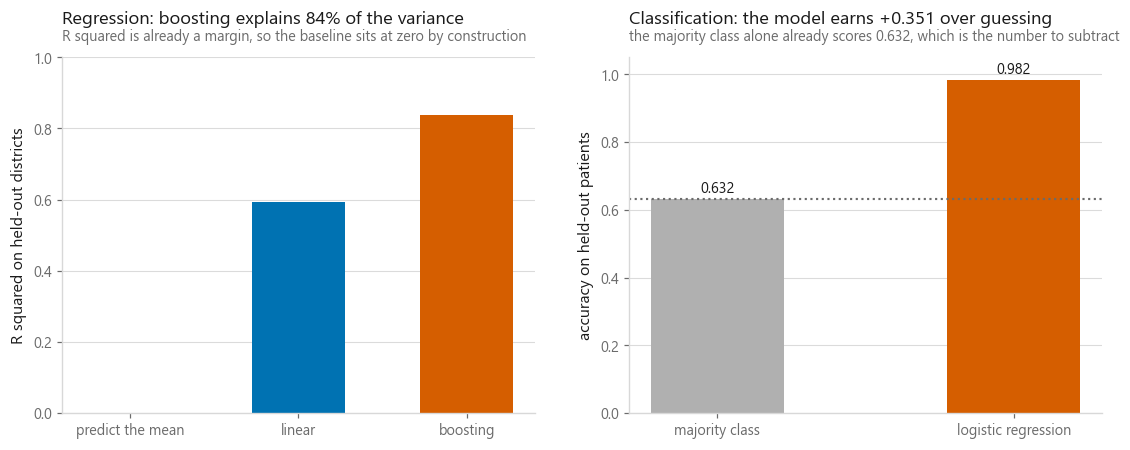

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2))

axes[0].bar(["predict the mean", "linear", "boosting"],
            [0.0, scores.loc[1, "R2"], scores.loc[2, "R2"]],
            color=[style.NEUTRAL, style.PALETTE[0], style.HIGHLIGHT], width=0.55)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("R squared on held-out districts")
style.title(axes[0],
            f"Regression: boosting explains {scores.loc[2, 'R2']:.0%} of the variance",
            "R squared is already a margin, so the baseline sits at zero by construction")

axes[1].bar(["majority class", "logistic regression"], [base_acc, model_acc],
            color=[style.NEUTRAL, style.HIGHLIGHT], width=0.45)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("accuracy on held-out patients")
axes[1].axhline(base_acc, color=style.MUTED, ls=":", lw=1.4)
for i, value in enumerate([base_acc, model_acc]):
    axes[1].annotate(f"{value:.3f}", (i, value), xytext=(0, 4),
                     textcoords="offset points", ha="center",
                     fontsize=9.5, color=style.INK)
style.title(axes[1],
            f"Classification: the model earns {model_acc - base_acc:+.3f} over guessing",
            f"the majority class alone already scores {base_acc:.3f}, which is the number to subtract")

style.save(fig, FIG / "fig-05-both-baselines.png")

The majority class alone scores respectably here, and on this dataset the model
still clears it by a wide margin. That will not always be so. When the class you
care about is rare the baseline climbs toward one and the margin collapses, and
accuracy stops being a usable measurement at all.
[01-05](../05-classification-metrics/) measures a case where a model that never
predicts the positive class is beaten by only three thousandths of accuracy, and
[03-07](../../03-classification/07-imbalanced-classes/) is the chapter about
what to do instead.

## 9. What would have to be true for this to be used

The gradient boosting model above takes a large bite out of the baseline. That
does not make it usable. Here is the list I would want answered before anyone
acted on its output, and it is a list of facts about the world rather than facts
about the code.

**The data is from the 1990 census.** Any use today assumes the relationship
between income, location and price has not moved in thirty-five years, which is
a claim nobody would sign. This is the ordinary case rather than a quirk of an
old dataset: models are fitted on the past and applied to the future, and the
gap between those is usually the largest source of error in the whole system.

**The rows are districts, not houses.** Every column is an average over a few
thousand people. A prediction is a statement about a district's median, and
applying it to one house is a different claim that this data cannot support.

**The target is censored.** Section 2 counted the districts stuck on the cap.
For those rows the model is being trained toward a number known to be wrong, and
section 7 showed the error that produces at the expensive end.

**Nobody has said what an error costs.** RMSE assumes a mistake of two units
hurts four times as much as a mistake of one, and that overpricing and
underpricing hurt equally. Both are assumptions about the decision the
prediction feeds, not properties of the data.
[01-06](../06-regression-metrics/) shows how much the choice of metric changes
which model wins.

**The held-out set was used once.** I fitted, scored, and reported. The moment I
start adjusting the model because I did not like the held-out number, that
number stops being an estimate of anything.
[01-02](../02-train-validation-test/) measures exactly how fast it decays.

## Cheat sheet

| | |
|---|---|
| **Supervised learning** | Fit a function from feature columns to a target column, using rows where both are known |
| **First model, always** | `DummyRegressor(strategy="mean")` or `DummyClassifier(strategy="most_frequent")`. One line, and it defines what winning means |
| **Report** | The model's score and the baseline's score, together. A score alone is not a result |
| **RMSE** | Same units as the target, punishes large mistakes hardest |
| **R squared** | One minus the ratio of squared errors to the constant predictor's. Zero is the baseline, negative is worse than doing nothing |
| **Accuracy** | Usable only next to the majority-class rate. Compare them before reading anything else |
| **Split** | Hold rows back before fitting. One split is enough to see the idea, not enough to trust a comparison |
| **Coefficients** | Describe the model. They are not causal claims about the world |
| **Do next** | Break the error down by a column and look at the pieces. It costs one `groupby` and it finds real problems |
| **Next chapter** | [Train, validation, test](../02-train-validation-test/), which is why one held-out set is not enough |

## What to remember

1. The workflow is load, look, split, baseline, fit, subtract, break down,
   write the caveats. The looking and the subtracting are the two steps people
   skip and the two that catch the most mistakes.
2. Predicting the mean is the exact least-squares solution when features are
   ignored, which is why it is the right thing to beat rather than a strawman.
3. A score without a baseline next to it cannot be interpreted by anybody,
   including the person who produced it.
4. $R^2$ is a margin over the mean already. Accuracy is not a margin over
   anything, so the majority-class rate has to be printed alongside it.
5. Scores computed on rows the model was fitted on measure memory. The split
   exists to stop that, and every later chapter is about the ways a split can
   still lie.
6. The average error hid a large positive bias at the cheap end cancelling a
   negative one at the top. Break errors down by something before believing a
   summary.
7. A coefficient describes the model. Reading it as a cause is the most common
   mistake in the whole subject, and
   [12-05](../../12-putting-it-together/05-common-mistakes/) collects the rest.
8. Finishing with a list of what would have to be true is part of the work, not
   a postscript to it.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [01-02 Train, validation, test](../02-train-validation-test/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#GettingStarted` `#Baseline` `#ScikitLearn` `#Python`
`#DataScience` `#MLTutorial` `#LearnMachineLearning` `#Regression` `#AI`